# Notebook 04 — Exploratory Data Analysis

Explore the engineered FIFA dataset using the reusable visualization utilities.

## 1. Imports ##

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
from pathlib import Path

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Connect ##

In [3]:
con = duckdb.connect()

con.execute("PRAGMA threads=8")
con.execute("PRAGMA memory_limit='8GB'")

PARQUET = PROCESSED_DATA_DIR / "players_clean"

## 3. Dataset Summary ##

In [4]:
summary = con.sql(f"""
SELECT

COUNT(*) AS players,

COUNT(DISTINCT club_name) AS clubs,

COUNT(DISTINCT league_name) AS leagues,

COUNT(DISTINCT nationality_name) AS countries

FROM parquet_scan('{PARQUET}')
""").df()

summary

,players,clubs,leagues,countries
0,10003590,1648,44,193


## 4. Missing Values ##

In [5]:
missing = con.sql(f"""
SELECT

SUM(value_eur IS NULL) value_missing,

SUM(wage_eur IS NULL) wage_missing,

SUM(club_name IS NULL) club_missing,

SUM(player_positions IS NULL) position_missing

FROM parquet_scan('{PARQUET}')
""").df()

missing

,value_missing,wage_missing,club_missing,position_missing
0,132797.0,115974.0,116395.0,0.0


## 5. League Distribution ##

In [6]:
league = con.sql(f"""
SELECT

league_name,

COUNT(*) AS players

FROM parquet_scan('{PARQUET}')

GROUP BY league_name

ORDER BY players DESC
""").df()

league.head()

,league_name,players
0,Premier League,558853
1,Bundesliga,466307
2,Serie A,460704
3,Liga Profesional,418639
4,Championship,399467


## 6. Plot League Distribution ##

In [7]:
fig = px.bar(
    league.head(20),
    x="league_name",
    y="players",
    title="Top 20 Leagues by Player Count",
)

fig.update_layout(
    xaxis_title="League",
    yaxis_title="Players",
    template="plotly_white",
)

fig.show()

fig.write_html(
    FIGURES_DIR / "league_distribution.html"
)

fig.write_image(
    FIGURES_DIR / "league_distribution.png",
    width=1400,
    height=800,
)

## 7. Age Distribution ##

In [8]:
age = con.sql(f"""
SELECT

TRY_CAST(age AS INTEGER) AS age

FROM parquet_scan('{PARQUET}')

WHERE TRY_CAST(age AS INTEGER) IS NOT NULL
""").df()

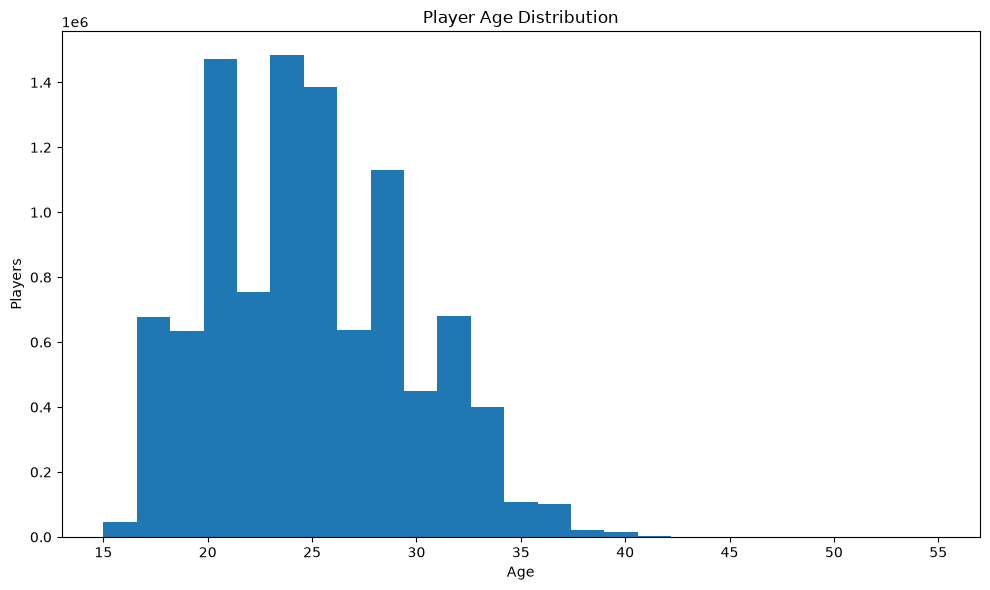

In [9]:
plt.figure(figsize=(10,6))

plt.hist(age["age"], bins=25)

plt.xlabel("Age")
plt.ylabel("Players")
plt.title("Player Age Distribution")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "age_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

## 8. Overall Rating Distribution ##

In [10]:
overall = con.sql(f"""
SELECT

TRY_CAST(overall AS INTEGER) AS overall

FROM parquet_scan('{PARQUET}')

WHERE TRY_CAST(overall AS INTEGER) IS NOT NULL
""").df()

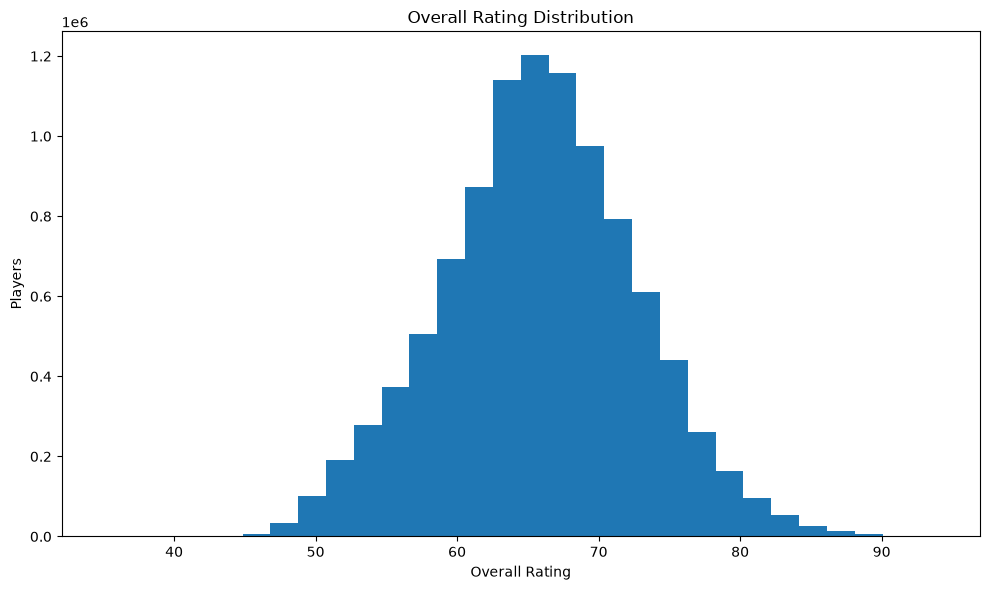

In [11]:
plt.figure(figsize=(10,6))

plt.hist(overall["overall"], bins=30)

plt.xlabel("Overall Rating")
plt.ylabel("Players")
plt.title("Overall Rating Distribution")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "overall_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

## 9. Top Clubs ##

In [12]:
clubs = con.sql(f"""
SELECT

club_name,

COUNT(*) players

FROM parquet_scan('{PARQUET}')

GROUP BY club_name

ORDER BY players DESC

LIMIT 20
""").df()

clubs

,club_name,players
0,NaN,116395
1,Everton,25614
2,River Plate,20041
3,Liverpool,19729
4,West Ham United,18386
5,Arsenal,18377
6,Crystal Palace,18377
7,Tottenham Hotspur,18372
8,Manchester United,18351
9,Leicester City,18335


## 10. Top Nationalities ##

In [13]:
countries = con.sql(f"""
SELECT

nationality_name,

COUNT(*) players

FROM parquet_scan('{PARQUET}')

GROUP BY nationality_name

ORDER BY players DESC

LIMIT 20
""").df()

In [14]:
fig = px.bar(
    countries,
    x="nationality_name",
    y="players",
    title="Top Nationalities",
)

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="Players",
    template="plotly_white",
)

fig.show()

fig.write_html(
    FIGURES_DIR / "top_nationalities.html"
)

fig.write_image(
    FIGURES_DIR / "top_nationalities.png",
    width=1400,
    height=800,
)

## 11. Market Value Statistics ##

In [15]:
market = con.sql(f"""
SELECT

MIN(TRY_CAST(value_eur AS DOUBLE)) AS minimum,

AVG(TRY_CAST(value_eur AS DOUBLE)) AS average,

MAX(TRY_CAST(value_eur AS DOUBLE)) AS maximum,

MEDIAN(TRY_CAST(value_eur AS DOUBLE)) AS median

FROM parquet_scan('{PARQUET}')
""").df()

market

,minimum,average,maximum,median
0,1000.0,2.292346e+06,194000000.0,725000.0


## 12. Correlation Sample ##

In [19]:
sample = con.sql(f"""
SELECT

TRY_CAST(overall AS DOUBLE) AS overall,
TRY_CAST(value_eur AS DOUBLE) AS market_value,
TRY_CAST(age AS DOUBLE) AS age,
TRY_CAST(potential AS DOUBLE) AS potential

FROM parquet_scan('{PARQUET}')

WHERE
    TRY_CAST(overall AS DOUBLE) IS NOT NULL
    AND TRY_CAST(value_eur AS DOUBLE) IS NOT NULL
    AND TRY_CAST(age AS DOUBLE) IS NOT NULL
    AND TRY_CAST(potential AS DOUBLE) IS NOT NULL

USING SAMPLE 100000 ROWS
""").df()

## 13. Correlation Matrix ##

In [22]:
sample.head()

,overall,market_value,age,potential
0,65.0,1600000.0,20.0,74.0
1,73.0,2500000.0,26.0,74.0
2,47.0,45000.0,18.0,57.0
3,64.0,650000.0,25.0,66.0
4,65.0,35000.0,39.0,65.0


In [23]:
sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 98606 entries, 0 to 98605
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   overall       98606 non-null  float64
 1   market_value  98606 non-null  float64
 2   age           98606 non-null  float64
 3   potential     98606 non-null  float64
dtypes: float64(4)
memory usage: 3.0 MB


In [24]:
corr = sample.corr(numeric_only=True)

corr

,overall,market_value,age,potential
overall,1.000000,0.579507,0.460266,0.688467
market_value,0.579507,1.000000,0.072525,0.543162
age,0.460266,0.072525,1.000000,-0.209270
potential,0.688467,0.543162,-0.209270,1.000000


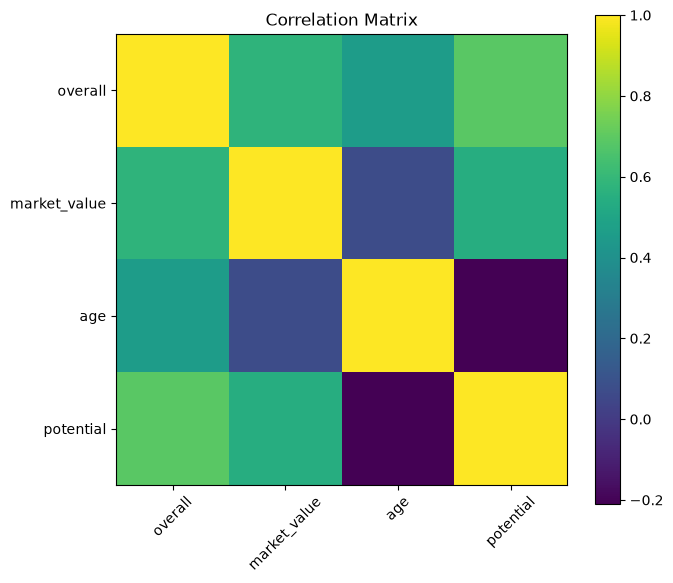

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(corr, interpolation="nearest")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

## 14. Save EDA Tables ##

In [26]:
league.to_csv(
    PROCESSED_DATA_DIR / "eda_league.csv",
    index=False,
)
league.to_parquet(
    PROCESSED_DATA_DIR / "eda_league.parquet",
    index=False,
)

clubs.to_csv(
    PROCESSED_DATA_DIR / "eda_clubs.csv",
    index=False,
)
clubs.to_parquet(
    PROCESSED_DATA_DIR / "eda_clubs.parquet",
    index=False,
)

countries.to_csv(
    PROCESSED_DATA_DIR / "eda_countries.csv",
    index=False,
)
countries.to_parquet(
    PROCESSED_DATA_DIR / "eda_countries.parquet",
    index=False,
)

## Key observations

- Summarize rating distributions.
- Identify notable outliers.
- Compare player positions and nationalities.
- Record insights to guide feature selection.

### Next
Proceed to **Notebook 05 — Interactive Visualizations**.